In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv("ASGN4/goog.csv")
# print(df.isna().sum())
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


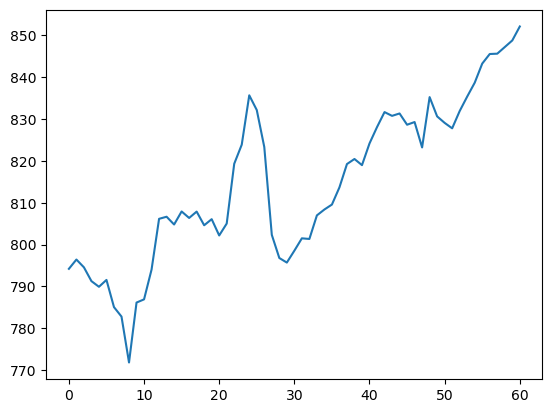

In [8]:
df_req=df['Close']
plt.plot(df_req)

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_req = scaler.fit_transform(np.array(df_req).reshape(-1,1))

In [10]:
# Split
training_size = int(len(df_req)*0.8)
df_train = df_req[:training_size, :]
df_test = df_req[training_size:len(df_req), :]

In [12]:
len(df_train), len(df_test)

(48, 13)

In [14]:
def create_dataset(data, step=4):
  x = []
  y = []
  for i in range(len(data) - step):
    x.append(data[i:i+step, 0])
    y.append(data[i+step, 0])

  return np.array(x), np.array(y)

# basically if dataset is [123 124 125 124 123 125 127]
# Independent 4 days  -> next day dependent
# s1  s1  s2  s3  y
# 123 124 125 124 123
# 124 125 124 123 125
# 125 124 123 125 127

x_train, y_train = create_dataset(df_train)
x_test, y_test = create_dataset(df_test)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM
model=Sequential()
# help(LSTM)
model.add(LSTM(50,return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
2/2 [==============================] - 3s 12ms/step - loss: 0.2597
Epoch 2/50
2/2 [==============================] - 0s 7ms/step - loss: 0.2251
Epoch 3/50
2/2 [==============================] - 0s 8ms/step - loss: 0.1945
Epoch 4/50
2/2 [==============================] - 0s 7ms/step - loss: 0.1636
Epoch 5/50
2/2 [==============================] - 0s 7ms/step - loss: 0.1359
Epoch 6/50
2/2 [==============================] - 0s 8ms/step - loss: 0.1065
Epoch 7/50
2/2 [==============================] - 0s 8ms/step - loss: 0.0808
Epoch 8/50
2/2 [==============================] - 0s 8ms/step - loss: 0.0575
Epoch 9/50
2/2 [==============================] - 0s 6ms/step - loss: 0.0379
Epoch 10/50
2/2 [==============================] - 0s 6ms/step - loss: 0.0245
Epoch 11/50
2/2 [==============================] - 0s 6ms/step - loss: 0.0210
Epoch 12/50
2/2 [==============================] - 0s 8ms/step - loss: 0.0250
Epoch 13/50
2/2 [==============================] - 0s 7ms/step - loss: 0

In [22]:
model.evaluate(x_test,y_test)

1/1 [==============================] - 1s 588ms/step - loss: 0.0171


0.017148349434137344

In [23]:
y_pred=scaler.inverse_transform(model.predict(x_test))
y_test=scaler.inverse_transform(np.array(y_test).reshape(-1,1))

1/1 [==============================] - 1s 580ms/step


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print('MAE: ', mae)
print('MSE: ', mse)
print('RMSE: ', rmse)

MAE:  10.089151940104166
MSE:  110.57419251301289
RMSE:  10.515426406618653


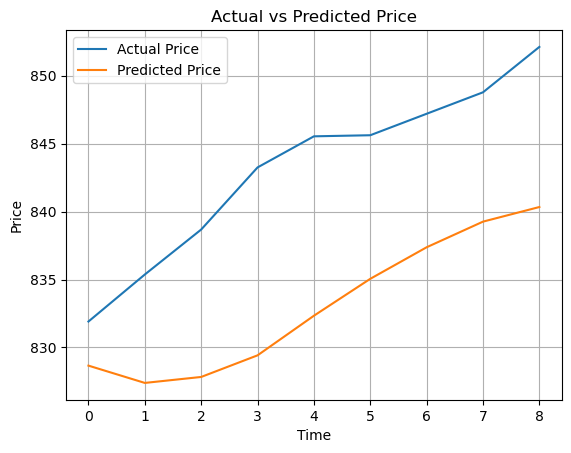

In [25]:
plt.plot(y_test, label='Actual Price')

# Plotting the predicted prices
plt.plot(y_pred, label='Predicted Price')

plt.title('Actual vs Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()